# **Import**

In [542]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

# **Import dataset**

In [543]:
df = pd.read_csv("ds_salaries.csv")

In [544]:
df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


0 : no remote work, 
50 : Hybrid, 
100 : Full remote

# **Dataset analysis**

In [545]:
# Dimensions
df.shape

(607, 12)

In [546]:
# Name and types of columns
df.dtypes

Unnamed: 0             int64
work_year              int64
experience_level      object
employment_type       object
job_title             object
salary                 int64
salary_currency       object
salary_in_usd          int64
employee_residence    object
remote_ratio           int64
company_location      object
company_size          object
dtype: object

In [547]:
# Missing values
df.isnull().sum()

Unnamed: 0            0
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [548]:
# Statistics
df.describe()

,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


In [549]:
#Column names
df.columns

Index(['Unnamed: 0', 'work_year', 'experience_level', 'employment_type',
       'job_title', 'salary', 'salary_currency', 'salary_in_usd',
       'employee_residence', 'remote_ratio', 'company_location',
       'company_size'],
      dtype='object')

# **Visualization**

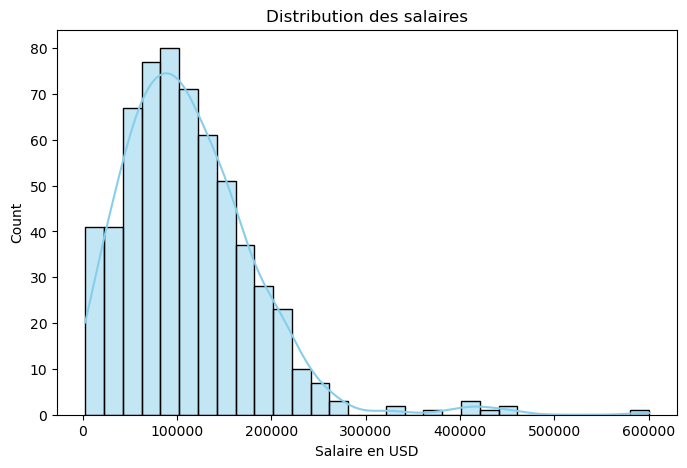

In [550]:
plt.figure(figsize=(8, 5))
sns.histplot(df['salary_in_usd'], kde=True, bins=30, color='skyblue')
plt.title("Distribution des salaires")
plt.xlabel("Salaire en USD")
plt.show()

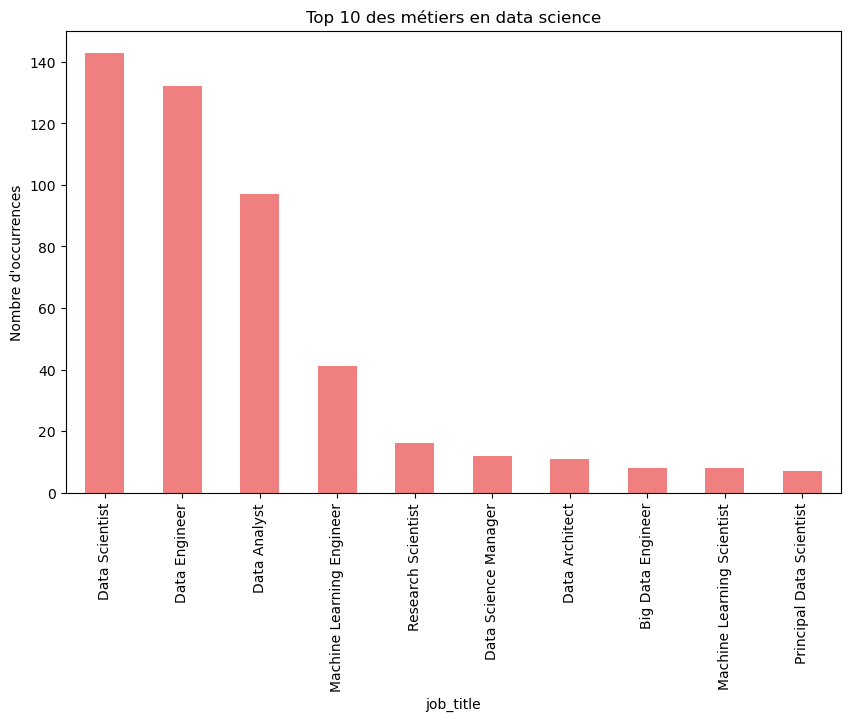

In [551]:
plt.figure(figsize=(10, 6))
df['job_title'].value_counts().head(10).plot(kind='bar', color='lightcoral')
plt.title("Top 10 des métiers en data science")
plt.ylabel("Nombre d'occurrences")
plt.show()

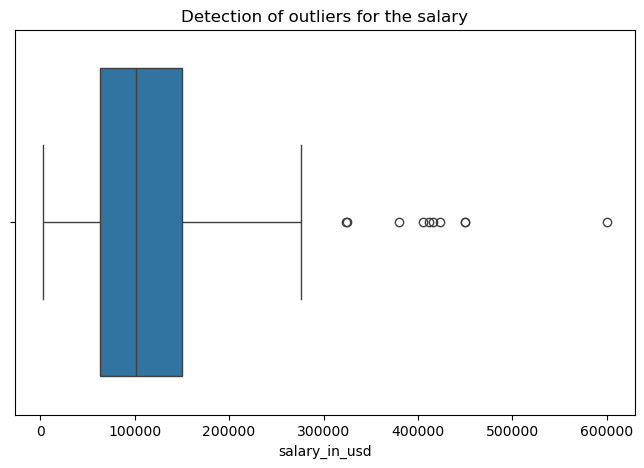

In [552]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['salary_in_usd'])
plt.title("Detection of outliers for the salary")
plt.show()

# **Duplicates**

In [553]:
df.duplicated().any()

np.False_

In [554]:
num_duplicates = df.duplicated().sum()
num_duplicates

np.int64(0)

In [555]:
df = df.drop_duplicates()

In [556]:
df.shape

(607, 12)

# **Encoding**

In [557]:
df['experience_level'] = df['experience_level'].map({
    'EN': 1,  # Entry-level / Junior
    'MI': 2,  # Mid-level / Intermediate
    'SE': 3,  # Senior-level
    'EX': 4   # Executive / Director
})

In [558]:
df['employment_type'] = df['employment_type'].map({
    'FT': 0,  # Full-time
    'PT': 1,  # Part-time
    'CT': 2,  # Contract
    'FL': 3   # Freelance
})

In [559]:
df['company_size'] = df['company_size'].map({
    'S': 1,  # Small (1–50 employees)
    'M': 2,  # Medium (51–500 employees)
    'L': 3   # Large (501+ employees)
})

In [560]:
job_counts = df['job_title'].value_counts().reset_index()
job_counts.columns = ['job_title', 'count']

rare_jobs = job_counts[job_counts['count'] < 10]
print(rare_jobs)

                                   job_title  count
7                          Big Data Engineer      8
8                 Machine Learning Scientist      8
9                   Principal Data Scientist      7
10                              AI Scientist      7
11                   Data Science Consultant      7
12                  Director of Data Science      7
13                    Data Analytics Manager      7
14                               ML Engineer      6
15                  Computer Vision Engineer      6
16                           BI Data Analyst      6
17                        Lead Data Engineer      6
18                  Data Engineering Manager      5
19                     Business Data Analyst      5
20                              Head of Data      5
21                    Applied Data Scientist      5
22        Applied Machine Learning Scientist      4
23                      Head of Data Science      4
24                        Analytics Engineer      4
25          

In [561]:
top_jobs = (df['job_title'].value_counts().head(15).index.tolist())
top_jobs

['Data Scientist',
 'Data Engineer',
 'Data Analyst',
 'Machine Learning Engineer',
 'Research Scientist',
 'Data Science Manager',
 'Data Architect',
 'Big Data Engineer',
 'Machine Learning Scientist',
 'Principal Data Scientist',
 'AI Scientist',
 'Data Science Consultant',
 'Director of Data Science',
 'Data Analytics Manager',
 'ML Engineer']

In [562]:
import pandas as pd
from rapidfuzz import fuzz, process  

top_jobs = (df['job_title'].value_counts().head(30).index.tolist())

def normalize_job(title):
    match, score, _ = process.extractOne(title, top_jobs, scorer=fuzz.token_sort_ratio)
    if score >= 55:  
        return match
    else:
        return title  


df['job_title_clean'] = df['job_title'].apply(normalize_job)

job_counts = df['job_title_clean'].value_counts().reset_index()
job_counts.columns = ['job_title_clean', 'count']

rare_jobs = job_counts[job_counts['count'] < 10]

print(rare_jobs)

df['job_title_clean'].nunique()

                             job_title_clean  count
7                 Machine Learning Scientist      9
8                     Data Analytics Manager      9
9                         Lead Data Engineer      9
10                  Director of Data Science      9
11                         Big Data Engineer      8
12                  Principal Data Scientist      7
13                  Computer Vision Engineer      7
14                              AI Scientist      7
15                               ML Engineer      7
16                   Data Science Consultant      7
17                           BI Data Analyst      6
18                  Data Engineering Manager      5
19                              Head of Data      5
20                    Applied Data Scientist      5
21                     Business Data Analyst      5
22                Machine Learning Developer      5
23                   Data Analytics Engineer      4
24        Applied Machine Learning Scientist      4
25          

30

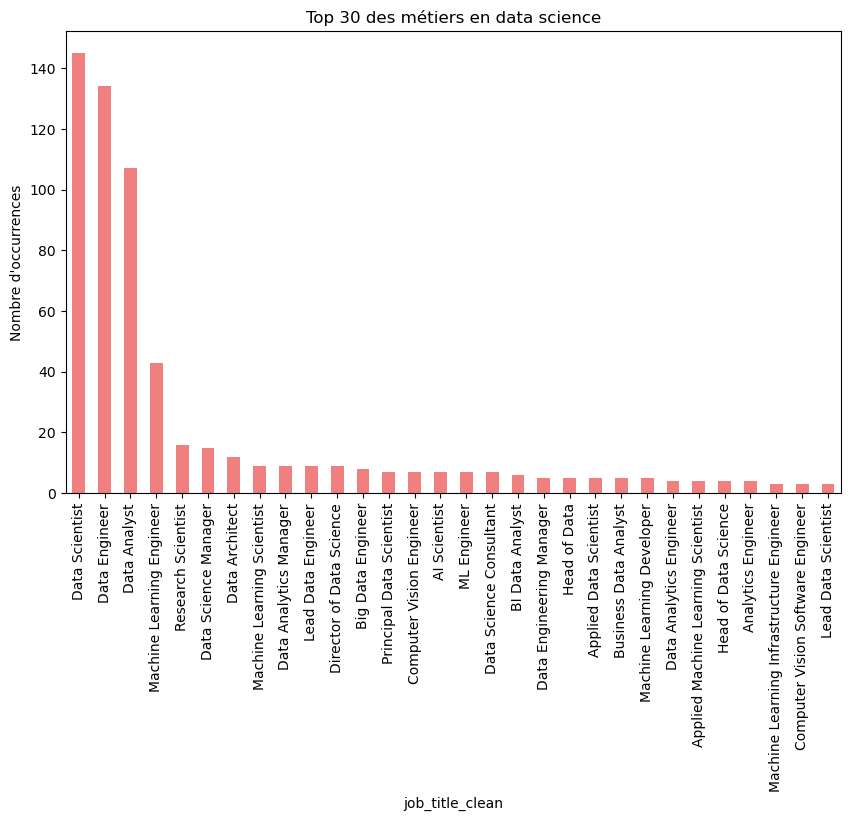

In [563]:

plt.figure(figsize=(10, 6))
df['job_title_clean'].value_counts().head(30).plot(kind='bar', color='lightcoral')
plt.title("Top 30 des métiers en data science")
plt.ylabel("Nombre d'occurrences")
plt.show()

In [564]:
job_counts = df['job_title'].value_counts()

df = df[df['job_title'].isin(job_counts[job_counts >= 10].index)]

In [565]:
df['job_title_clean'].nunique()

7

In [566]:
df = df.drop(columns=['job_title'])

In [567]:
df.shape

(452, 12)

In [568]:
# We are going to do a label encoding but we are looking for a better solution
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

df['job_title_encoded'] = encoder.fit_transform(df['job_title_clean'])
df['company_location_encoded']= encoder.fit_transform(df['company_location'])

In [569]:
df.dtypes

Unnamed: 0                   int64
work_year                    int64
experience_level             int64
employment_type              int64
salary                       int64
salary_currency             object
salary_in_usd                int64
employee_residence          object
remote_ratio                 int64
company_location            object
company_size                 int64
job_title_clean             object
job_title_encoded            int64
company_location_encoded     int64
dtype: object

In [570]:
df_final =  df.drop(columns=['job_title_clean'])
df_final.describe()

,Unnamed: 0,work_year,experience_level,employment_type,salary,salary_in_usd,remote_ratio,company_size,job_title_encoded,company_location_encoded
count,452.000000,452.000000,452.000000,452.000000,4.520000e+02,452.000000,452.000000,452.000000,452.000000,452.000000
mean,329.303097,2021.502212,2.384956,0.024336,2.950824e+05,108987.035398,70.907080,2.174779,2.619469,28.632743
std,169.989236,0.677477,0.724940,0.224509,1.609135e+06,60266.625927,41.317764,0.601536,1.783485,11.765355
min,0.000000,2020.000000,1.000000,0.000000,4.000000e+03,2859.000000,0.000000,1.000000,0.000000,0.000000
25%,197.750000,2021.000000,2.000000,0.000000,6.945000e+04,65000.000000,50.000000,2.000000,2.000000,15.000000
50%,336.500000,2022.000000,3.000000,0.000000,1.107125e+05,100000.000000,100.000000,2.000000,2.000000,37.000000
75%,473.250000,2022.000000,3.000000,0.000000,1.570000e+05,144213.500000,100.000000,3.000000,4.000000,37.000000
max,605.000000,2022.000000,4.000000,3.000000,3.040000e+07,450000.000000,100.000000,3.000000,6.000000,38.000000


In [571]:
df_final = df_final.drop(columns=['salary_currency'], axis=1)
df_final = df_final.drop(columns=['employee_residence'], axis=1)
df_final = df_final.drop(columns=['company_location'], axis=1)
df_final = df_final.drop(columns=['Unnamed: 0'], axis=1)
df_final.dtypes

work_year                   int64
experience_level            int64
employment_type             int64
salary                      int64
salary_in_usd               int64
remote_ratio                int64
company_size                int64
job_title_encoded           int64
company_location_encoded    int64
dtype: object

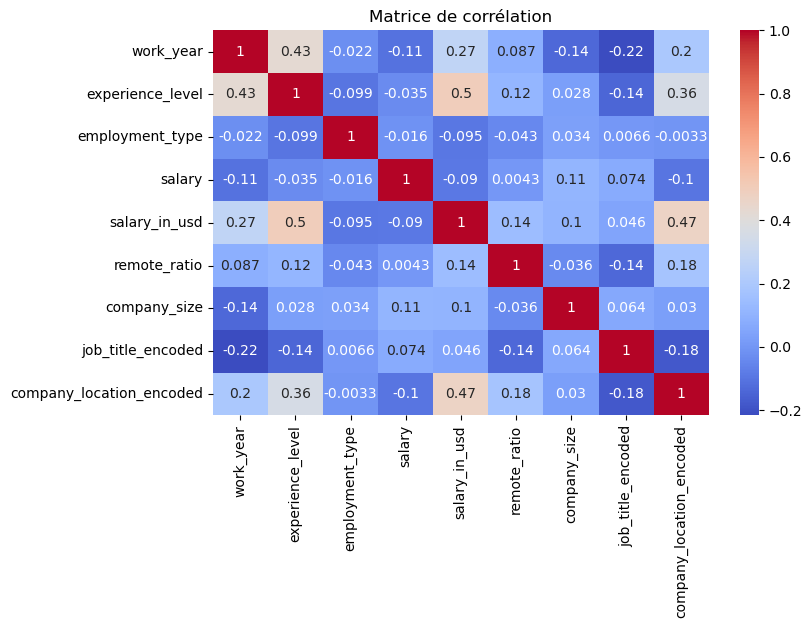

In [572]:
#heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df_final.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()

# **Outliers**

In [573]:
from scipy import stats

z_scores = stats.zscore(df_final['salary_in_usd'])

df_no_outliers = df_final[abs(z_scores) < 5]  

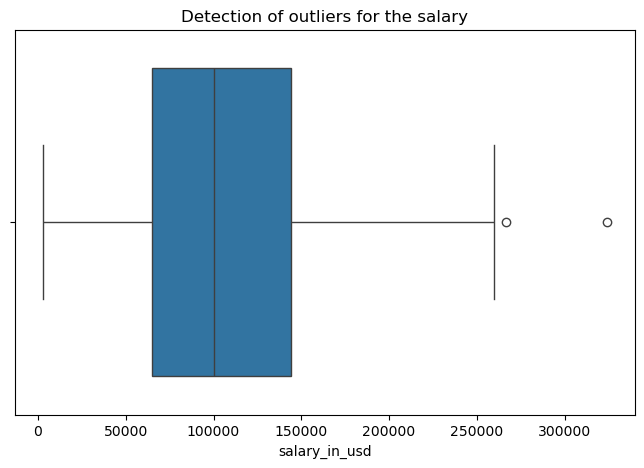

In [574]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_no_outliers['salary_in_usd'])
plt.title("Detection of outliers for the salary")
plt.show()

## **Formalisation of the problem**

The objective of this project is to develop a machine learning model capable of predicting employees salaries based on their professional and job-related characteristics. By analyzing features such as experience level, employment type, remote work ratio, company size, and job title, the model aims to capture the key factors that influence salary levels. The ultimate goal is to provide an accurate, data-driven tool that supports fair salary estimation and informed decision-making within the job market.

## **Model**

In [575]:
y= df_no_outliers['salary_in_usd']
X = df_no_outliers.drop(columns=['salary_in_usd'], axis=1)

In [576]:
y.head()

0      79833
4     150000
5      72000
7      35735
10     51321
Name: salary_in_usd, dtype: int64

In [577]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=20)

In [578]:
#from sklearn.preprocessing import StandardScaler
#scaler = StandardScaler()
#X_train_scaled = scaler.fit_transform(X_train)
#X_test_scaled = scaler.transform(X_test)

In [579]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [580]:
model.fit(X_train, y_train)

LinearRegression()

In [581]:
y_pred = model.predict(X_test)

In [582]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error =", mse)
print("R² Score =", r2)

Mean Squared Error = 1792249118.9355586
R² Score = 0.38887883384982447
